In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
"""
Task 1: Simple Tic-Tac-Toe AI Agent
        The AI uses the Minimax algorithm to always pick the best move.
        Human plays as X, AI plays as O.
"""

# ─────────────────────────────────────────────
# DEFINE THE GAME BOARD
# ─────────────────────────────────────────────

def create_board():
    return [' '] * 9

def display_board(board):
    print("\n")
    print(f" {board[0]} | {board[1]} | {board[2]} ")
    print("---|---|---")
    print(f" {board[3]} | {board[4]} | {board[5]} ")
    print("---|---|---")
    print(f" {board[6]} | {board[7]} | {board[8]} ")
    print()

# ─────────────────────────────────────────────
# CHECK WIN / TIE
# ─────────────────────────────────────────────

def check_winner(board, player):
    wins = [(0,1,2),(3,4,5),(6,7,8),
            (0,3,6),(1,4,7),(2,5,8),
            (0,4,8),(2,4,6)]
    for a, b, c in wins:
        if board[a] == board[b] == board[c] == player:
            return True
    return False

def check_tie(board):
    return ' ' not in board

# ─────────────────────────────────────────────
# AI AGENT — MINIMAX
# ─────────────────────────────────────────────

def get_ai_move(board):
    best_score = -float('inf')
    best_move = None
    for i in range(9):
        if board[i] == ' ':
            board[i] = 'O'
            score = minimax(board, False)
            board[i] = ' '
            if score > best_score:
                best_score = score
                best_move = i
    return best_move

def minimax(board, is_maximizing):
    if check_winner(board, 'O'):
        return 1
    if check_winner(board, 'X'):
        return -1
    if check_tie(board):
        return 0

    if is_maximizing:
        best = -float('inf')
        for i in range(9):
            if board[i] == ' ':
                board[i] = 'O'
                best = max(best, minimax(board, False))
                board[i] = ' '
        return best
    else:
        best = float('inf')
        for i in range(9):
            if board[i] == ' ':
                board[i] = 'X'
                best = min(best, minimax(board, True))
                board[i] = ' '
        return best

# ─────────────────────────────────────────────
# MAIN GAME LOOP
# ─────────────────────────────────────────────


def main():

    print("=== Tic-Tac-Toe: You (X) vs AI (O) ===")

    while True:  # Outer loop for replaying the game

        print("\nPositions are numbered 1–9:\n")
        print(" 1 | 2 | 3 ")
        print("---|---|---")
        print(" 4 | 5 | 6 ")
        print("---|---|---")
        print(" 7 | 8 | 9 \n")

        board = create_board()

        # Single game loop
        while True:
            display_board(board)

            # Human move
            while True:
                try:
                    move = int(input("Your move (1-9): ")) - 1

                    if 0 <= move <= 8 and board[move] == ' ':
                        break

                    print("Invalid move. Try again.")

                except ValueError:
                    print("Enter a number between 1 and 9.")

            board[move] = 'X'

            # Check if player wins
            if check_winner(board, 'X'):
                display_board(board)
                print("You win! Congratulations!")
                break

            # Check tie
            if check_tie(board):
                display_board(board)
                print("It's a tie!")
                break

            # AI move
            ai_move = get_ai_move(board)
            board[ai_move] = 'O'

            print(f"AI plays at position {ai_move + 1}")

            # Check if AI wins
            if check_winner(board, 'O'):
                display_board(board)
                print("AI wins!")
                break

            # Check tie
            if check_tie(board):
                display_board(board)
                print("It's a tie!")
                break

        # Ask if player wants another game
        play_again = input("\nPlay again? (y/n): ").lower()

        if play_again != 'y':
            print("Thanks for playing!")
            break


# Start the game
main()

=== Tic-Tac-Toe: You (X) vs AI (O) ===

Positions are numbered 1–9:

 1 | 2 | 3 
---|---|---
 4 | 5 | 6 
---|---|---
 7 | 8 | 9 



   |   |   
---|---|---
   |   |   
---|---|---
   |   |   



Your move (1-9):  3


AI plays at position 5


   |   | X 
---|---|---
   | O |   
---|---|---
   |   |   



Your move (1-9):  3


Invalid move. Try again.


...

AI plays at position 9


   | O | X 
---|---|---
   | O |   
---|---|---
 X | X | O 



Your move (1-9):  1


AI plays at position 4


 X | O | X 
---|---|---
 O | O |   
---|---|---
 X | X | O 



Your move (1-9):  6




 X | O | X 
---|---|---
 O | O | X 
---|---|---
 X | X | O 

It's a tie!


In [4]:
"""
Task 2: Matplotlib Exercises using company_sales_data.csv
        Exercise 1 – Total profit of all months (line plot)
        Exercise 2 – Bathing soap and facewash of all months (subplot)
"""

# Load data using read_csv
df = pd.read_csv("company_sales_data.csv")

months = df['month_number']


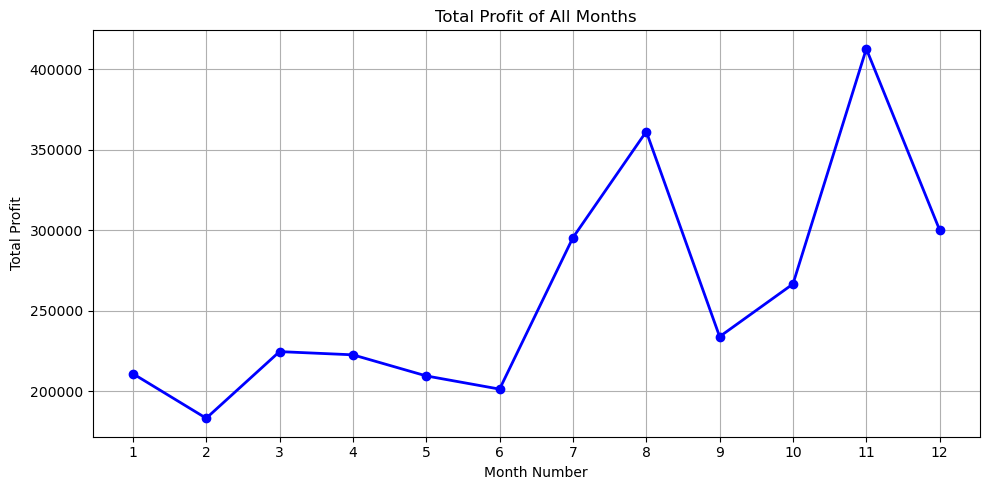

In [5]:
# ─────────────────────────────────────────────
# Exercise 1: Total Profit Line Plot
# ─────────────────────────────────────────────

plt.figure(figsize=(10, 5))
plt.plot(months, df['total_profit'], marker='o', color='blue', linewidth=2)
plt.title('Total Profit of All Months')
plt.xlabel('Month Number')
plt.ylabel('Total Profit')
plt.xticks(months)
plt.grid(True)
plt.tight_layout()

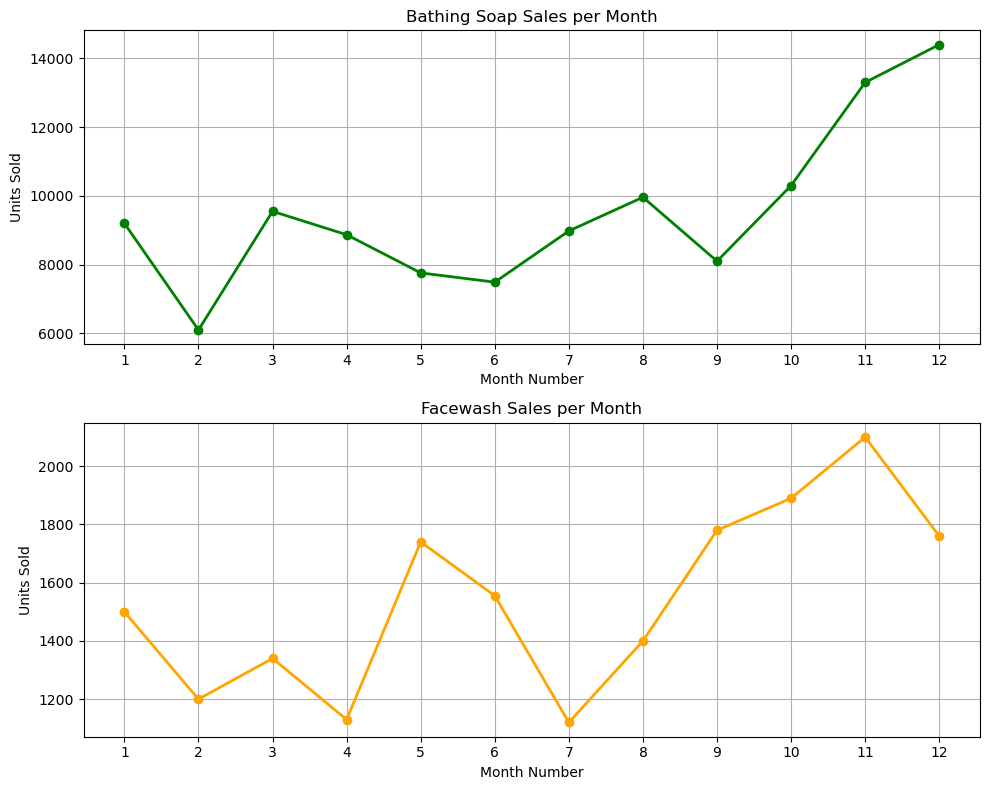

In [6]:
# ─────────────────────────────────────────────
# Exercise 2: Bathing Soap & Facewash Subplot
# ─────────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(months, df['bathingsoap'], marker='o', color='green', linewidth=2)
ax1.set_title('Bathing Soap Sales per Month')
ax1.set_xlabel('Month Number')
ax1.set_ylabel('Units Sold')
ax1.set_xticks(months)
ax1.grid(True)

ax2.plot(months, df['facewash'], marker='o', color='orange', linewidth=2)
ax2.set_title('Facewash Sales per Month')
ax2.set_xlabel('Month Number')
ax2.set_ylabel('Units Sold')
ax2.set_xticks(months)
ax2.grid(True)

plt.tight_layout()
